# Project Overview

This notebook contains an end-to-end machine learning workflow:
- Data loading
- Data preprocessing
- EDA
- Model training and evaluation

⚠️ The dataset is not included in this repository due to size/licensing.
Download link is provided in the README.


# **Preprocessing**

In [ ]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import models libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Import evaluation libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, roc_auc_score

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go


In [ ]:
df = pd.read_csv('Student_Depression_Dataset.csv')

In [ ]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [ ]:
df.tail()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1
27900,140699,Male,27.0,Patna,Student,4.0,0.0,9.24,1.0,0.0,Less than 5 hours,Healthy,BCA,Yes,2.0,3.0,Yes,1


In [ ]:
df.sample(5)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
14289,72226,Female,29.0,Mumbai,Student,5.0,0.0,8.96,1.0,0.0,7-8 hours,Moderate,B.Tech,No,11.0,1.0,No,0
27783,140018,Male,33.0,Meerut,Student,4.0,0.0,5.88,5.0,0.0,More than 8 hours,Moderate,M.Tech,No,8.0,3.0,No,0
26612,134242,Female,30.0,Rajkot,Student,1.0,0.0,9.44,5.0,0.0,More than 8 hours,Moderate,MSc,No,10.0,2.0,No,0
23529,118550,Female,21.0,Thane,Student,1.0,0.0,7.94,1.0,0.0,More than 8 hours,Healthy,MSc,No,8.0,3.0,Yes,0
4960,24886,Male,32.0,Chennai,Student,3.0,0.0,7.83,5.0,0.0,More than 8 hours,Moderate,BE,No,5.0,1.0,No,0


In [ ]:
df.shape

(27901, 18)

In [ ]:
df.dtypes

,0
id,int64
Gender,object
Age,float64
City,object
Profession,object
Academic Pressure,float64
Work Pressure,float64
CGPA,float64
Study Satisfaction,float64
Job Satisfaction,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [ ]:
df.describe(include="all")

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,27901.000000,27901,27901.000000,27901,27901,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901,27901,27901,27901,27901.000000,27898.000000,27901,27901.000000
unique,NaN,2,NaN,52,14,NaN,NaN,NaN,NaN,NaN,5,4,28,2,NaN,NaN,2,NaN
top,NaN,Male,NaN,Kalyan,Student,NaN,NaN,NaN,NaN,NaN,Less than 5 hours,Unhealthy,Class 12,Yes,NaN,NaN,No,NaN
freq,NaN,15547,NaN,1570,27870,NaN,NaN,NaN,NaN,NaN,8310,10317,6080,17656,NaN,NaN,14398,NaN
mean,70442.149421,NaN,25.822300,NaN,NaN,3.141214,0.000430,7.656104,2.943837,0.000681,NaN,NaN,NaN,NaN,7.156984,3.139867,NaN,0.585499
std,40641.175216,NaN,4.905687,NaN,NaN,1.381465,0.043992,1.470707,1.361148,0.044394,NaN,NaN,NaN,NaN,3.707642,1.437347,NaN,0.492645
min,2.000000,NaN,18.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,1.000000,NaN,0.000000
25%,35039.000000,NaN,21.000000,NaN,NaN,2.000000,0.000000,6.290000,2.000000,0.000000,NaN,NaN,NaN,NaN,4.000000,2.000000,NaN,0.000000
50%,70684.000000,NaN,25.000000,NaN,NaN,3.000000,0.000000,7.770000,3.000000,0.000000,NaN,NaN,NaN,NaN,8.000000,3.000000,NaN,1.000000
75%,105818.000000,NaN,30.000000,NaN,NaN,4.000000,0.000000,8.920000,4.000000,0.000000,NaN,NaN,NaN,NaN,10.000000,4.000000,NaN,1.000000


In [ ]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.strip() \
                       .str.lower() \
                       .str.replace(' ', '_') \
                       .str.replace('/', '_') \
                       .str.replace(r'[^\w_]', '', regex=True) #r'[^\w_]' removes all special characters except letters, numbers, and underscores.

print(df.columns.tolist())


['id', 'gender', 'age', 'city', 'profession', 'academic_pressure', 'work_pressure', 'cgpa', 'study_satisfaction', 'job_satisfaction', 'sleep_duration', 'dietary_habits', 'degree', 'have_you_ever_had_suicidal_thoughts_', 'work_study_hours', 'financial_stress', 'family_history_of_mental_illness', 'depression']


In [ ]:
#handling categorical columns
categorical_cols = ['dietary_habits', 'city', 'profession']
for col in categorical_cols:
  df[col] = df[col].str.strip().str.lower()


In [ ]:
#handling gender into 0 and 1
df['gender'] = df['gender'].str.strip().str.lower().map({'male': 0, 'female': 1})


In [ ]:
#handling dietary_habits col using one hot encoding
df = pd.get_dummies(df, columns=['dietary_habits'], prefix='diet')
#now I'll be having the new cols: diet_healthy, diet_moderate, diet_unhealthy

In [ ]:
df['diet_healthy']

,diet_healthy
0,True
1,False
2,True
3,False
4,False
...,...
27896,False
27897,True
27898,False
27899,True


In [ ]:
#handling yes/no columns
yes_no_cols = ['have_you_ever_had_suicidal_thoughts_', 'family_history_of_mental_illness']
for col in yes_no_cols:
  df[col] = df[col].str.strip().str.lower()
  df[col] = df[col].map({'yes': 1, 'no': 0})

In [ ]:
df['sleep_duration'].value_counts() #to check all the values possible

,count
sleep_duration,
Less than 5 hours,8310
7-8 hours,7346
5-6 hours,6183
More than 8 hours,6044
Others,18


In [ ]:
# Map sleep_duration to numeric values
sleep_map = {
    'less than 5 hours': 4,
    '5-6 hours': 5.5,
    '7-8 hours': 7.5,
    'more than 8 hours': 9,
    'others': 6
}

df['sleep_duration'] = (
    df['sleep_duration']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(sleep_map)
)

# Fill missing values with median
df['sleep_duration'] = df['sleep_duration'].fillna(df['sleep_duration'].median())


In [ ]:
df['sleep_duration']

,sleep_duration
0,5.5
1,5.5
2,4.0
3,7.5
4,5.5
...,...
27896,5.5
27897,4.0
27898,5.5
27899,4.0


In [ ]:
df['sleep_duration'].unique()

array([5.5, 4. , 7.5, 9. , 6. ])

In [ ]:
df['degree'].value_counts()

,count
degree,
Class 12,6080
B.Ed,1867
B.Com,1506
B.Arch,1478
BCA,1433
MSc,1190
B.Tech,1152
MCA,1044
M.Tech,1022


In [ ]:
#handling degree col
def map_degree(deg):
    deg = str(deg).strip().lower()
    if deg.startswith('b') and deg not in ['mbbs']:
        return 'bachelor'
    elif deg.startswith('m') and deg not in ['md', 'mbbs']:
        return 'master'
    elif 'phd' in deg:
        return 'doctorate'
    elif deg in ['mbbs', 'md']:
        return 'medical'
    elif deg.startswith('ll'):  # llb, llm
        return 'law'
    else:
        return 'other'

df['degree'] = df['degree'].apply(map_degree)



In [ ]:
print(df['degree'].unique())

['bachelor' 'master' 'doctorate' 'other' 'law' 'medical']


In [ ]:
df.describe(include="all")

,id,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,...,degree,have_you_ever_had_suicidal_thoughts_,work_study_hours,financial_stress,family_history_of_mental_illness,depression,diet_healthy,diet_moderate,diet_others,diet_unhealthy
count,27901.000000,27901.000000,27901.000000,27901,27901,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,...,27901,27901.000000,27901.000000,27898.000000,27901.000000,27901.000000,27901,27901,27901,27901
unique,NaN,NaN,NaN,52,14,NaN,NaN,NaN,NaN,NaN,...,6,NaN,NaN,NaN,NaN,NaN,2,2,2,2
top,NaN,NaN,NaN,kalyan,student,NaN,NaN,NaN,NaN,NaN,...,bachelor,NaN,NaN,NaN,NaN,NaN,False,False,False,False
freq,NaN,NaN,NaN,1570,27870,NaN,NaN,NaN,NaN,NaN,...,11968,NaN,NaN,NaN,NaN,NaN,20250,17980,27889,17584
mean,70442.149421,0.442780,25.822300,NaN,NaN,3.141214,0.000430,7.656104,2.943837,0.000681,...,NaN,0.632809,7.156984,3.139867,0.483961,0.585499,NaN,NaN,NaN,NaN
std,40641.175216,0.496724,4.905687,NaN,NaN,1.381465,0.043992,1.470707,1.361148,0.044394,...,NaN,0.482048,3.707642,1.437347,0.499752,0.492645,NaN,NaN,NaN,NaN
min,2.000000,0.000000,18.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,35039.000000,0.000000,21.000000,NaN,NaN,2.000000,0.000000,6.290000,2.000000,0.000000,...,NaN,0.000000,4.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,70684.000000,0.000000,25.000000,NaN,NaN,3.000000,0.000000,7.770000,3.000000,0.000000,...,NaN,1.000000,8.000000,3.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
75%,105818.000000,1.000000,30.000000,NaN,NaN,4.000000,0.000000,8.920000,4.000000,0.000000,...,NaN,1.000000,10.000000,4.000000,1.000000,1.000000,NaN,NaN,NaN,NaN


In [ ]:
df['city'] = df['city'].astype("category")

In [ ]:
df['profession'] = df['profession'].astype("category")

In [ ]:
df['degree'] = df['degree'].astype("category")

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
city,0
profession,0
academic_pressure,0
work_pressure,0
cgpa,0
study_satisfaction,0
job_satisfaction,0


In [ ]:
#handling nulls:
df['financial_stress'].fillna(df['financial_stress'].median(), inplace=True)

/tmp/ipython-input-2931001618.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['financial_stress'].fillna(df['financial_stress'].median(), inplace=True)


In [ ]:
df.isna().sum()

,0
id,0
gender,0
age,0
city,0
profession,0
academic_pressure,0
work_pressure,0
cgpa,0
study_satisfaction,0
job_satisfaction,0


In [ ]:
df.dtypes

,0
id,int64
gender,int64
age,float64
city,category
profession,category
academic_pressure,float64
work_pressure,float64
cgpa,float64
study_satisfaction,float64
job_satisfaction,float64


In [ ]:
#One hot encoding
df = pd.get_dummies(df, columns=['city', 'profession', 'degree'], drop_first=True)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 87 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    27901 non-null  int64  
 1   gender                                27901 non-null  int64  
 2   age                                   27901 non-null  float64
 3   academic_pressure                     27901 non-null  float64
 4   work_pressure                         27901 non-null  float64
 5   cgpa                                  27901 non-null  float64
 6   study_satisfaction                    27901 non-null  float64
 7   job_satisfaction                      27901 non-null  float64
 8   sleep_duration                        27901 non-null  float64
 9   have_you_ever_had_suicidal_thoughts_  27901 non-null  int64  
 10  work_study_hours                      27901 non-null  float64
 11  financial_stres

In [ ]:
city_cols = [col for col in df.columns if col.startswith("city_")]
df = df.drop(columns=city_cols)
# Dropped city columns because they are noisy, inconsistent, and not predictive for depression

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 36 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    27901 non-null  int64  
 1   gender                                27901 non-null  int64  
 2   age                                   27901 non-null  float64
 3   academic_pressure                     27901 non-null  float64
 4   work_pressure                         27901 non-null  float64
 5   cgpa                                  27901 non-null  float64
 6   study_satisfaction                    27901 non-null  float64
 7   job_satisfaction                      27901 non-null  float64
 8   sleep_duration                        27901 non-null  float64
 9   have_you_ever_had_suicidal_thoughts_  27901 non-null  int64  
 10  work_study_hours                      27901 non-null  float64
 11  financial_stres

Preprocessing done so far:
1. Clean columns
2. Clean categorical values
3. Map gender
4. Map yes/no
5. Map sleep_duration
6. Map degree
7. One-hot dietary_habits
8. One-hot city, profession, degree


In [ ]:
'''The reason one hot encoding is done is that ml models can't understand text only numbers so categorical data is converted into numerical format '''

"The reason one hot encoding is done is that ml models can't understand text only numbers so categorical data is converted into numerical format "

# **Visualization**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipython-input-607671284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='depression', data=df, palette='Set2')


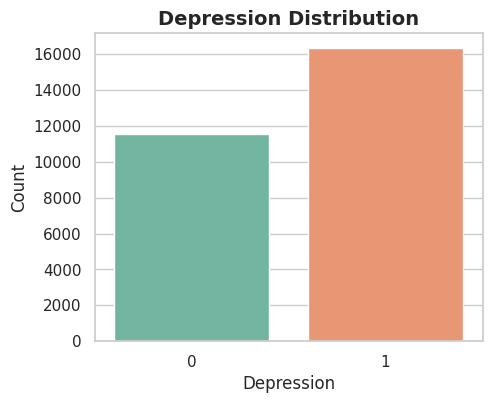

In [ ]:
#Target Distribution
sns.set(style="whitegrid")

plt.figure(figsize=(5,4))
sns.countplot(x='depression', data=df, palette='Set2')
plt.title("Depression Distribution", fontsize=14, weight='bold')
plt.xlabel("Depression")
plt.ylabel("Count")
plt.show()

In [ ]:
#Shows how many students are labeled “depressed” vs “not depressed.”

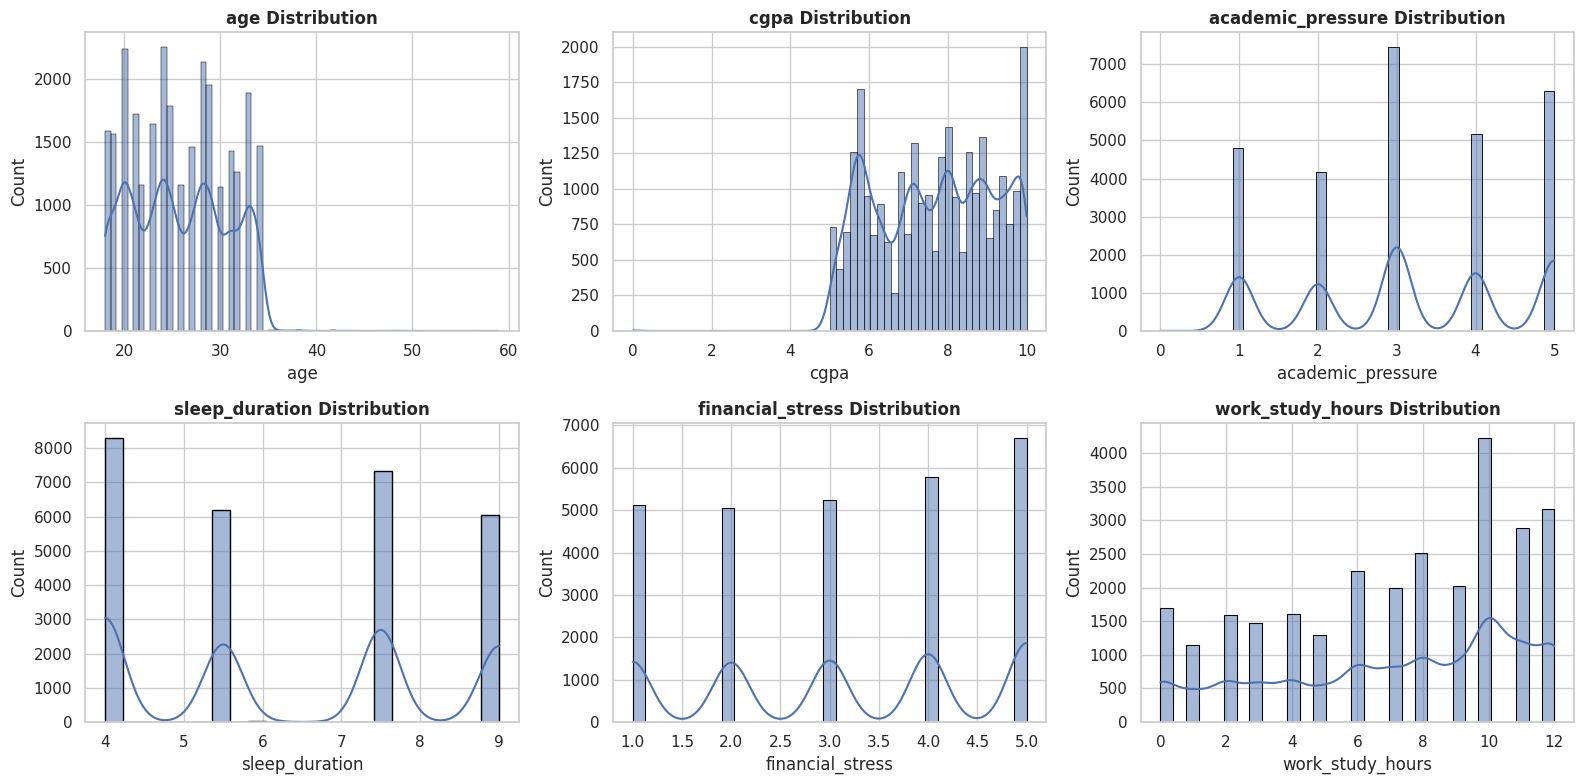

In [ ]:
# HISTOGRAMS OF NUMERICAL FEATURES
num_cols = [
    'age',
    'cgpa',
    'academic_pressure',
    'sleep_duration',
    'financial_stress',
    'work_study_hours'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for idx, col in enumerate(num_cols):
    r, c = divmod(idx, 3)
    sns.histplot(df[col], kde=True, ax=axes[r][c], edgecolor='black')
    axes[r][c].set_title(f'{col} Distribution', fontsize=12, weight='bold')
    axes[r][c].set_xlabel(col)

plt.tight_layout()
plt.show()

In [ ]:
'''
age: nearly symmetric. balanced

cgpa: nearly symmetric, tiny left skew. left skew -> most values are big, few are small

academic_pressure: nearly symmetric, slight left skew.

sleep_duration: symmetric.

financial_stress: symmetric.

work_study_hours: slightly left skewed
'''

'\nage: nearly symmetric. balanced\n\ncgpa: nearly symmetric, tiny left skew. left skew -> most values are big, few are small\n\nacademic_pressure: nearly symmetric, slight left skew.\n\nsleep_duration: symmetric.\n\nfinancial_stress: symmetric.\n\nwork_study_hours: slightly left skewed\n'

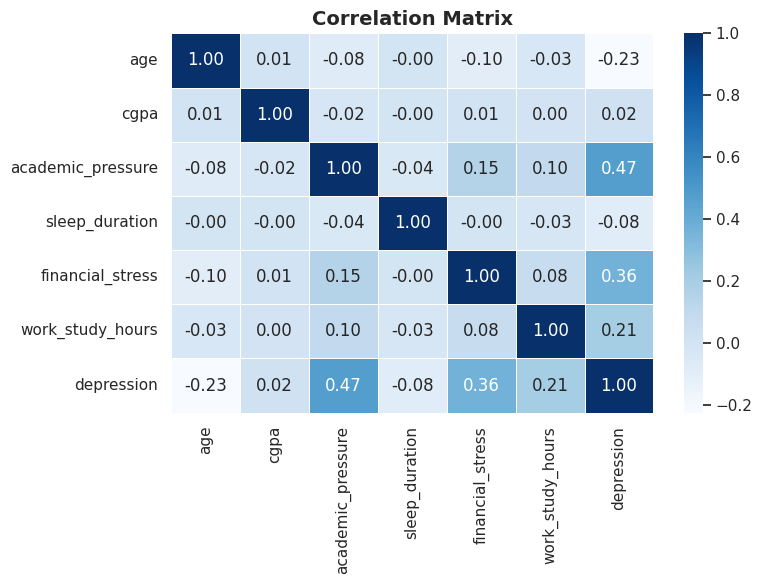

In [ ]:
# CORRELATION MATRIX (INCLUDES TARGET)
corr_cols = num_cols + ['depression']

plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [ ]:
'''
Academic Pressure (0.47): As academic pressure increases, the level of depression tends to increase noticeably.

Financial Stress (0.36): Students with higher financial stress are more likely to experience higher depression levels.

Work/Study Hours (0.21): Spending more hours studying or working is slightly associated with higher depression.

Age (-0.23): Older students tend to show slightly lower levels of depression compared to younger ones.

Sleep Duration (-0.08): The amount of sleep has almost no meaningful relationship with depression in this dataset.

CGPA (0.02): Academic performance shows virtually no connection to depression levels.
'''

'\nAcademic Pressure (0.47): As academic pressure increases, the level of depression tends to increase noticeably.\n\nFinancial Stress (0.36): Students with higher financial stress are more likely to experience higher depression levels.\n\nWork/Study Hours (0.21): Spending more hours studying or working is slightly associated with higher depression.\n\nAge (-0.23): Older students tend to show slightly lower levels of depression compared to younger ones.\n\nSleep Duration (-0.08): The amount of sleep has almost no meaningful relationship with depression in this dataset.\n\nCGPA (0.02): Academic performance shows virtually no connection to depression levels.\n'

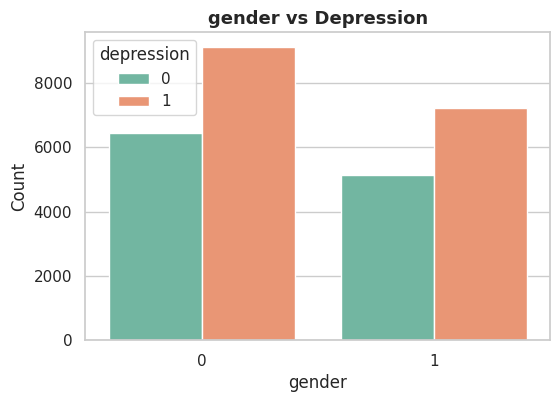

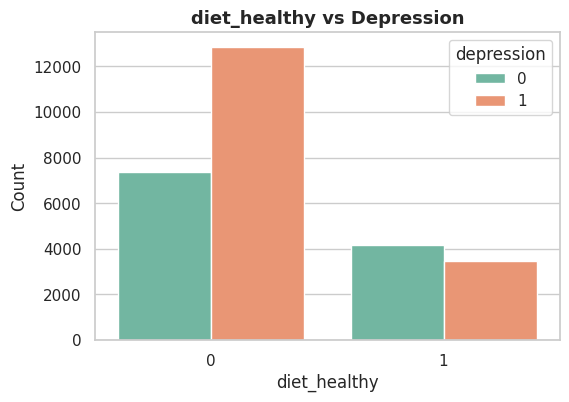

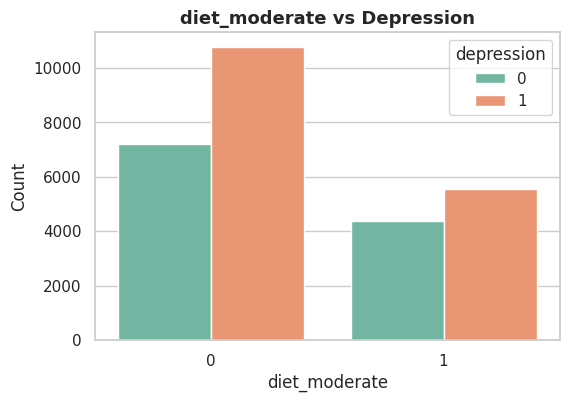

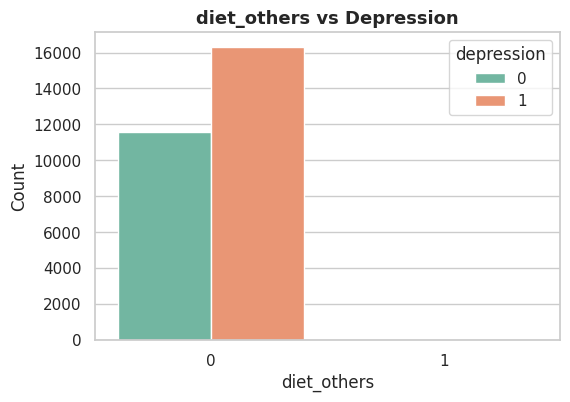

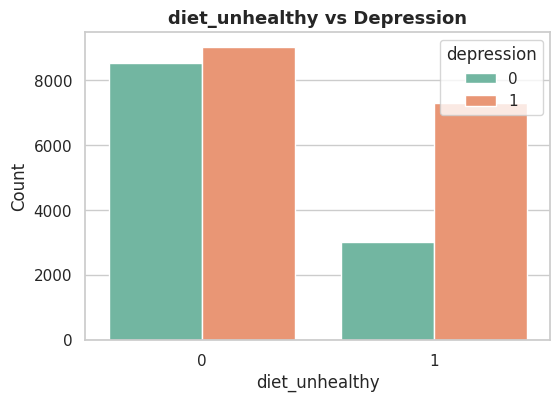

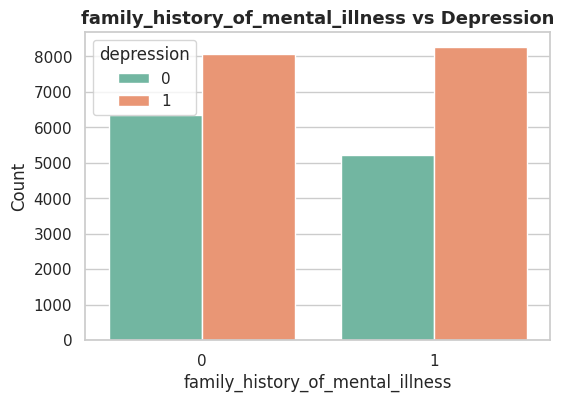

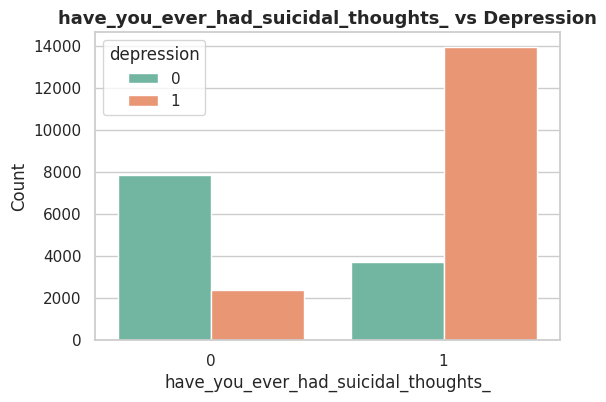

In [ ]:
# CATEGORICAL FEATURES vs DEPRESSION
cat_cols = [
    'gender',
    'diet_healthy', 'diet_moderate', 'diet_others', 'diet_unhealthy',
    'family_history_of_mental_illness',
    'have_you_ever_had_suicidal_thoughts_'
]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='depression', data=df, palette='Set2')
    plt.title(f"{col} vs Depression", fontsize=13, weight='bold')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

/tmp/ipython-input-1987985869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=col, y='depression', palette='Set2')


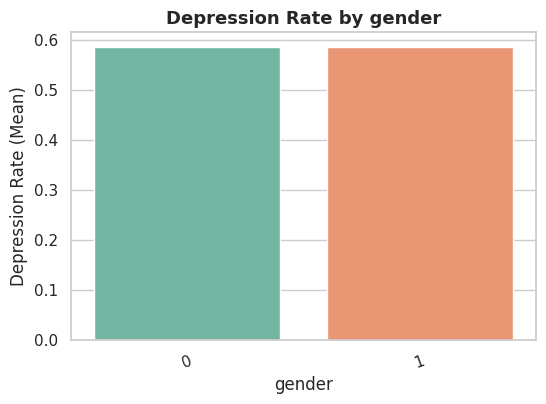

/tmp/ipython-input-1987985869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=col, y='depression', palette='Set2')


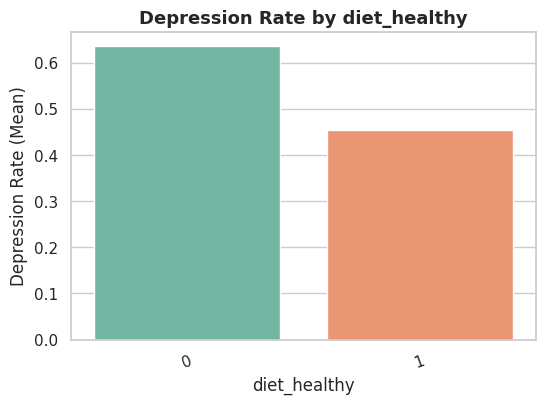

/tmp/ipython-input-1987985869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=col, y='depression', palette='Set2')


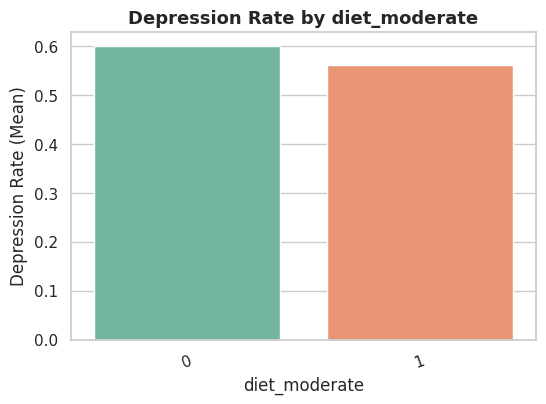

/tmp/ipython-input-1987985869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=col, y='depression', palette='Set2')


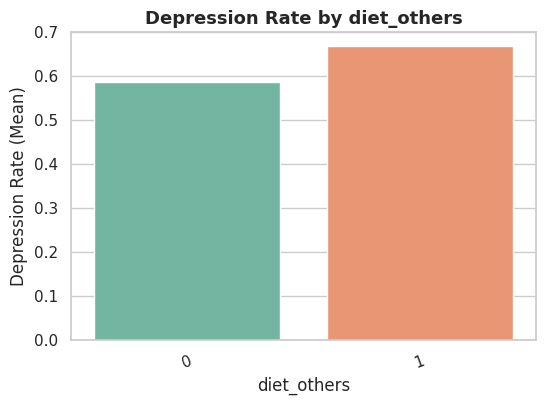

/tmp/ipython-input-1987985869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=col, y='depression', palette='Set2')


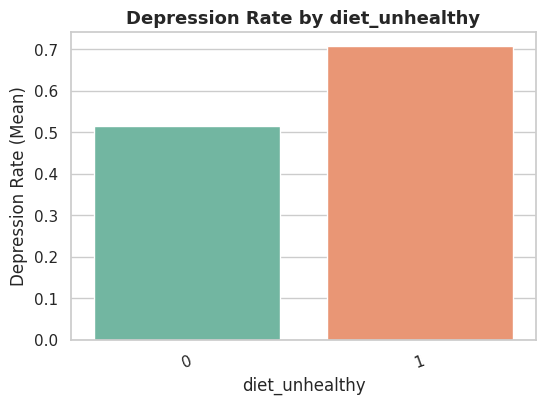

/tmp/ipython-input-1987985869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=col, y='depression', palette='Set2')


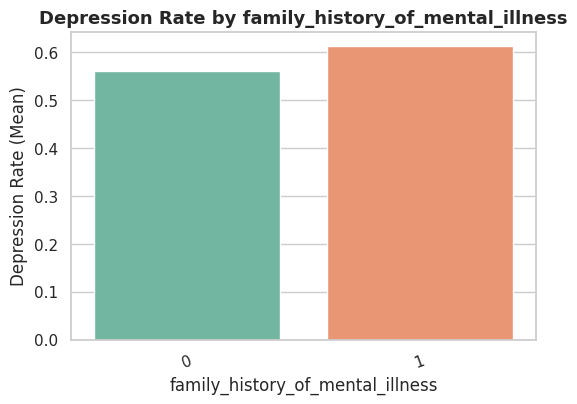

/tmp/ipython-input-1987985869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=col, y='depression', palette='Set2')


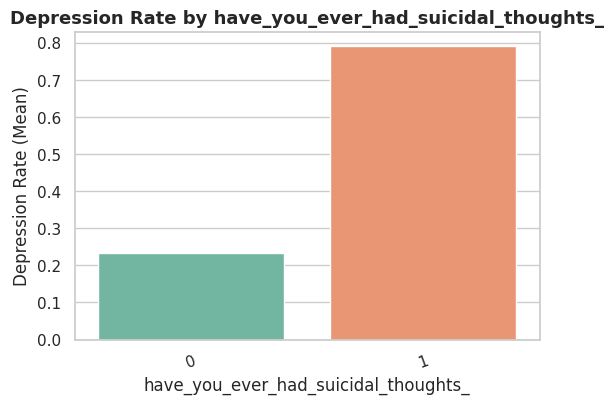

In [ ]:
# BINARY RATE PLOTS (percentage depressed per category)
for col in cat_cols:
    plt.figure(figsize=(6,4))

    rate = df.groupby(col)['depression'].mean().reset_index()
    sns.barplot(data=rate, x=col, y='depression', palette='Set2')

    plt.title(f"Depression Rate by {col}", fontsize=13, weight='bold')
    plt.ylabel("Depression Rate (Mean)")
    plt.xticks(rotation=20)
    plt.show()

/tmp/ipython-input-3888296539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='depression', y=col, data=df, palette='Set2', ax=axes[r][c])
/tmp/ipython-input-3888296539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='depression', y=col, data=df, palette='Set2', ax=axes[r][c])
/tmp/ipython-input-3888296539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='depression', y=col, data=df, palette='Set2', ax=axes[r][c])
/tmp/ipython-input-3888296539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and

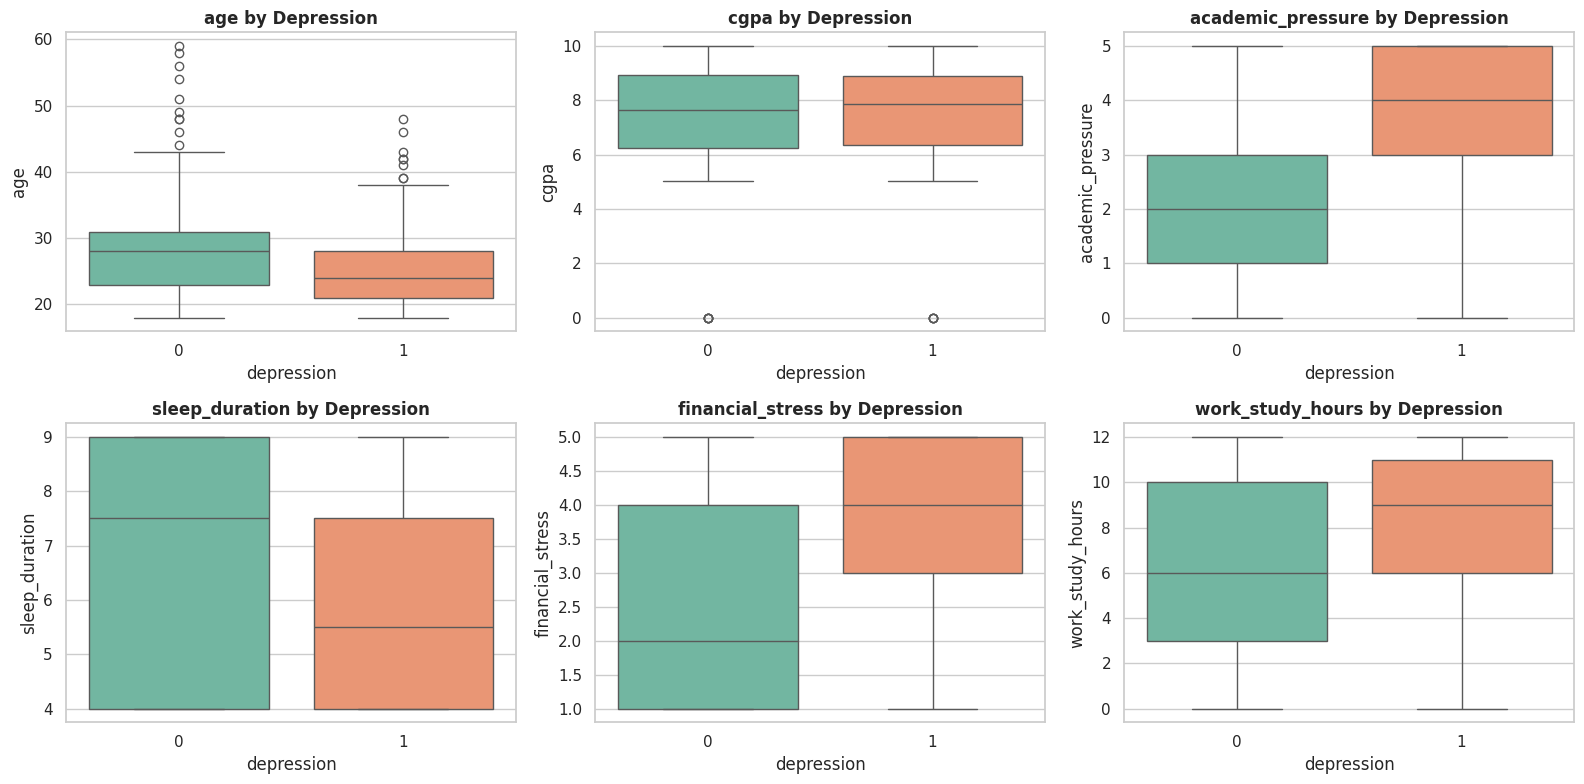

In [ ]:
# NUMERIC FEATURE DISTRIBUTION BY DEPRESSION (BOXPLOTS)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for idx, col in enumerate(num_cols):
    r, c = divmod(idx, 3)
    sns.boxplot(x='depression', y=col, data=df, palette='Set2', ax=axes[r][c])
    axes[r][c].set_title(f'{col} by Depression', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['depression'])   # features
y = df['depression']                  # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# Dropping "id" column so that it doesn't affect on prediction resutls
X_train = X_train.drop(columns=['id'])
X_test = X_test.drop(columns=['id'])


In [ ]:
#CAPPING
# Compute thresholds from TRAIN ONLY
age_upper = X_train['age'].quantile(0.95)
cgpa_lower = X_train['cgpa'].quantile(0.05)
'''
Age: anything above the top 5% is considered extreme
CGPA: anything below the bottom 5% is considered extreme
goal:
Prevents data leakage
Keeps test data truly unseen
example:
95th percentile = 45
50 → becomes 45
60 → becomes 45
30 → stays 30
'''

'\nAge: anything above the top 5% is considered extreme\nCGPA: anything below the bottom 5% is considered extreme\ngoal:\nPrevents data leakage\nKeeps test data truly unseen\nexample:\n95th percentile = 45\n50 → becomes 45\n60 → becomes 45\n30 → stays 30\n'

In [ ]:
def cap_values(df, col, lower=None, upper=None):
    if lower is not None:
        df[col] = df[col].apply(lambda x: max(x, lower))
    if upper is not None:
        df[col] = df[col].apply(lambda x: min(x, upper))
    return df

# Apply to train
X_train = cap_values(X_train.copy(), 'age', upper=age_upper)
X_train = cap_values(X_train, 'cgpa', lower=cgpa_lower)

# Apply SAME thresholds to test
X_test = cap_values(X_test.copy(), 'age', upper=age_upper)
X_test = cap_values(X_test, 'cgpa', lower=cgpa_lower)


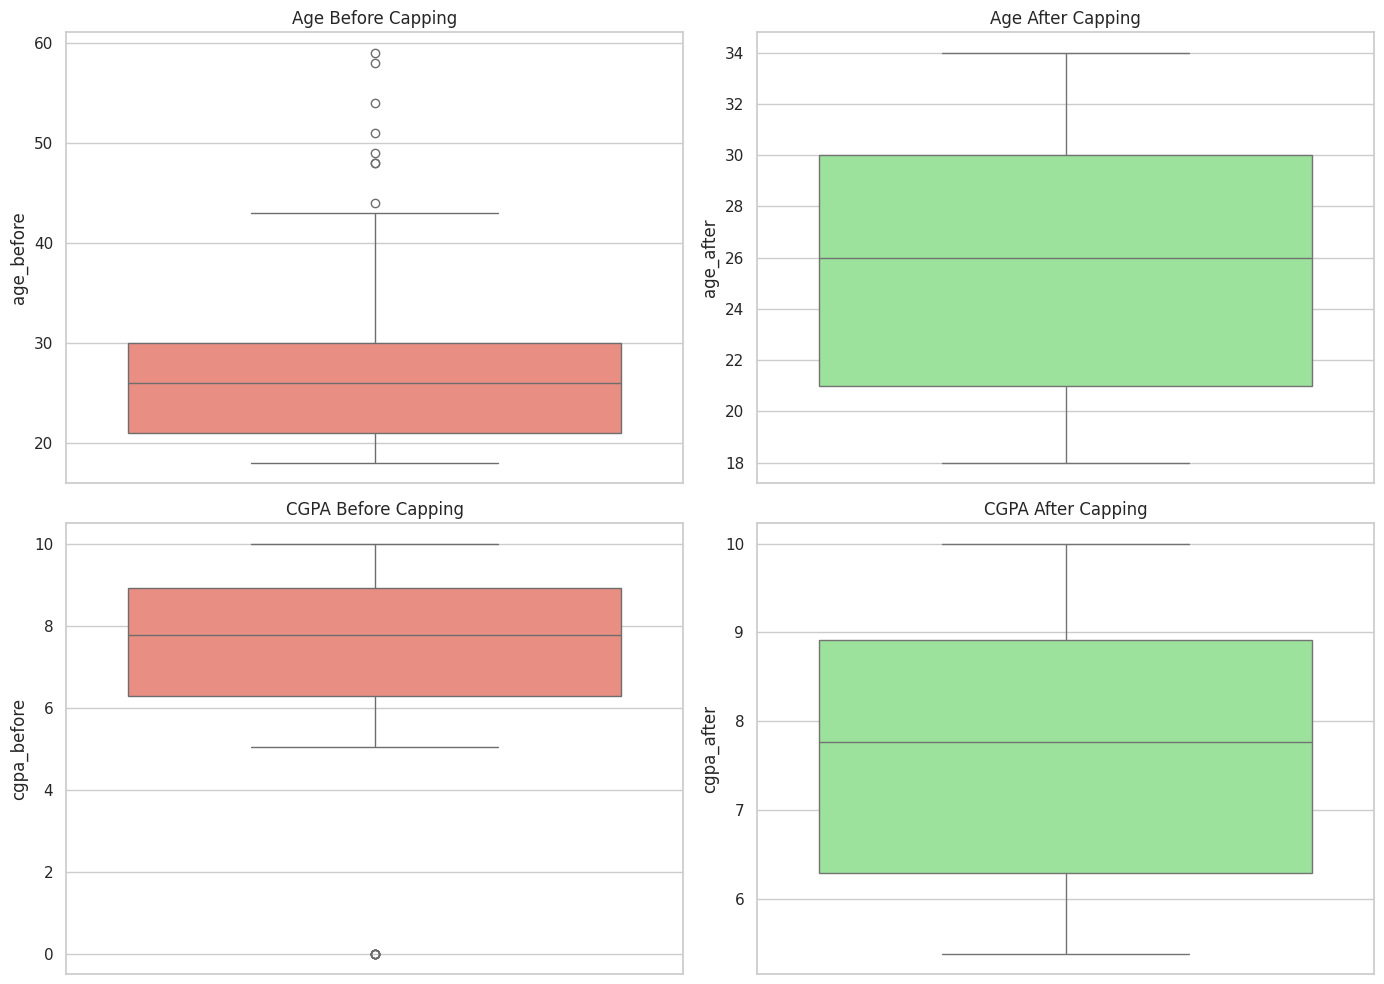

In [ ]:
# Before vs After Capping (Age & CGPA)

sns.set(style="whitegrid")

# Combine pre-cap and post-cap for train only
train_compare = X_train.copy()
train_compare['age_before'] = df.loc[X_train.index, 'age']
train_compare['cgpa_before'] = df.loc[X_train.index, 'cgpa']

# After capping
train_compare['age_after'] = X_train['age']
train_compare['cgpa_after'] = X_train['cgpa']

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age Before
sns.boxplot(y=train_compare['age_before'], ax=axes[0,0], color='salmon')
axes[0,0].set_title("Age Before Capping")

# Age After
sns.boxplot(y=train_compare['age_after'], ax=axes[0,1], color='lightgreen')
axes[0,1].set_title("Age After Capping")

# CGPA Before
sns.boxplot(y=train_compare['cgpa_before'], ax=axes[1,0], color='salmon')
axes[1,0].set_title("CGPA Before Capping")

# CGPA After
sns.boxplot(y=train_compare['cgpa_after'], ax=axes[1,1], color='lightgreen')
axes[1,1].set_title("CGPA After Capping")

plt.tight_layout()
plt.show()


In [ ]:
# Summary on outlier counts before vs after
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

print("Before Capping:")
print("Age:", count_outliers(train_compare, 'age_before'))
print("CGPA:", count_outliers(train_compare, 'cgpa_before'))

print("\nAfter Capping:")
print("Age:", count_outliers(train_compare, 'age_after'))
print("CGPA:", count_outliers(train_compare, 'cgpa_after'))

# IQR method is used to verify that the number of outliers decreased after capping.


Before Capping:
Age: 8
CGPA: 7

After Capping:
Age: 0
CGPA: 0


In [ ]:
# Scale Numerical Features
from sklearn.preprocessing import StandardScaler

scale_cols = ['age', 'cgpa', 'academic_pressure', 'sleep_duration',
              'financial_stress', 'work_study_hours']

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

'''
fit on the training data only because the goal
is to have the model learn parameters from the training data, and then use those
learned parameters to transform the test data without leaking information from the test set.

The model thinks large-range features are more important, which causes data leakage

 '''

'\nfit on the training data only because the goal\nis to have the model learn parameters from the training data, and then use those\nlearned parameters to transform the test data without leaking information from the test set.\n\nThe model thinks large-range features are more important, which causes data leakage\n\n '

## **Feature Engineering**

In [ ]:
epsilon = 1e-5 #This is a tiny number added to avoid division by zero.

for df_ in [X_train, X_test]:

    df_['stress_ratio'] = (df_['academic_pressure'].fillna(0) +
                           df_['work_pressure'].fillna(0))
#Instead of treating them separately, the model gets a combined stress indicator.
#High value → student is overwhelmed from both sides
#Low value → manageable stress levels

    df_['sleep_to_study_ratio'] = df_['sleep_duration'].fillna(0) / \
                                  (df_['work_study_hours'].fillna(0) + epsilon)
#How much sleep a student gets compared to how much they study/work.
#High ratio → good balance (more sleep than study pressure)
#Low ratio → unhealthy lifestyle (little sleep, lots of work)

    df_['total_stress'] = df_[['academic_pressure', 'work_pressure',
                               'financial_stress']].fillna(0).sum(axis=1)
#Mental health is often affected by cumulative stress, not just one source.
#High total_stress → higher risk of burnout/depression
#Low total_stress → more stable mental state

    df_['mental_risk'] = df_[['have_you_ever_had_suicidal_thoughts_',
                              'family_history_of_mental_illness']].fillna(0).sum(axis=1)
#converting two serious flags into a single risk indicator the model can understand.
#0 → no risk signs
#1 → moderate concern
#2 → high concern
#This creates a clear signal for prediction.

    df_['diet_score'] = (df_['diet_healthy'].fillna(0) * 4 +
                         df_['diet_moderate'].fillna(0) * 3 +
                         df_['diet_others'].fillna(0) * 2 +
                         df_['diet_unhealthy'].fillna(0) * 1)
#Instead of random categories, you gave meaningful weights.
#4 → very healthy diet
#1 → very unhealthy diet
#This tells the model: Diet quality directly impacts mental and physical health.

#This way we taught the model how to understand human life stress.

In [ ]:
#Evaluation Function
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name="Model"):
    print(f"\n===== {model_name} =====")

    # Train predictions
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    # Test predictions
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # Train metrics
    print("\n--- TRAIN METRICS ---")
    print(f"Accuracy : {accuracy_score(y_train, y_train_pred):.4f}") #Correct predictions / Total predictions
    print(f"Precision: {precision_score(y_train, y_train_pred):.4f}") #acc of the prediction whether it's true or not, ex: When the model says “YES, this person is at risk”, how often is it correct? the rest precisino is high then few false predictions
    print(f"Recall   : {recall_score(y_train, y_train_pred):.4f}") #Out of all truly at-risk people, how many did the model catch? High recall = model misses very few dangerous cases.
    print(f"F1 Score : {f1_score(y_train, y_train_pred):.4f}") #Balance between Precision and Recall
    print(f"ROC-AUC  : {roc_auc_score(y_train, y_train_prob):.4f}") # How well the model separates class 0 and class 1. Values range: 0.5 = random guessing, 1.0 = perfect model. if near 1 the model is very strong at distinguishing between: at risk na not at risk

    # Test metrics
    print("\n--- TEST METRICS ---")
    print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_test_pred):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_test_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_prob):.4f}")

    # Confusion matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))

    '''
    [ [TN   FP]
  [FN   TP] ]
  '''


# **Training**

**Logistic Regression**

In [ ]:
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

evaluate_classifier(log_reg, X_train, y_train, X_test, y_test, "Logistic Regression")



===== Logistic Regression =====

--- TRAIN METRICS ---
Accuracy : 0.8480
Precision: 0.8574
Recall   : 0.8881
F1 Score : 0.8725
ROC-AUC  : 0.9220

--- TEST METRICS ---
Accuracy : 0.8445
Precision: 0.8578
Recall   : 0.8804
F1 Score : 0.8689
ROC-AUC  : 0.9184

Confusion Matrix:
[[1836  477]
 [ 391 2877]]


In [ ]:
'''
Highest test F1
Best ROC–AUC=
NO overfitting
Balanced precision & recall

True Negatives (1836)
Correctly predicted as NOT at risk.

 False Positives (477)
Predicted as at risk but actually not.
= false alarm

 False Negatives (391)
Predicted as safe but actually at risk.
This is the most dangerous type.

 True Positives (2877)
Correctly identified as at risk.
'''
#The data is linearly separable enough, so Logistic Regression can draw a good separating line.

'\nHighest test F1\nBest ROC–AUC=\nNO overfitting\nBalanced precision & recall\n\nTrue Negatives (1845)\nCorrectly predicted as NOT at risk.\n\n False Positives (468)\nPredicted as at risk but actually not.\n= false alarm\n\n False Negatives (393)\nPredicted as safe but actually at risk.\nThis is the most dangerous type.\n\n True Positives (2875)\nCorrectly identified as at risk.\n'

**Random Forest**

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

evaluate_classifier(rf, X_train, y_train, X_test, y_test, "Random Forest")



===== Random Forest =====

--- TRAIN METRICS ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000

--- TEST METRICS ---
Accuracy : 0.8357
Precision: 0.8491
Recall   : 0.8748
F1 Score : 0.8618
ROC-AUC  : 0.9109

Confusion Matrix:
[[1805  508]
 [ 409 2859]]


In [ ]:
'''
Overfitting
Train = 1.00 across everything
Test = worse than Logistic Regression

Reason: it is memorizing the train data because the dataset is structured and not huge.

200 decision trees
Each tree learned complex rules
Together they over-memorised training data
so it became: Perfect at homework, but slightly worse at real exam.


TN	Correctly predicted not-at-risk	1805
FP Predicted risk but not actually	508
FN	Missed real risk cases	409
TP	Correctly predicted risk	2859
'''
#model memorised training examples rather than learning general patterns, making Logistic Regression more reliable for real-world prediction in this case.

'\nOverfitting\nTrain = 1.00 across everything\nTest = worse than Logistic Regression\n\nReason: it is memorizing the train data because the dataset is structured and not huge.\n\n200 decision trees\nEach tree learned complex rules\nTogether they over-memorised training data\nso it became: Perfect at homework, but slightly worse at real exam.\n\n\nTN\tCorrectly predicted not-at-risk\t1804\nFP Predicted risk but not actually\t509\nFN\tMissed real risk cases\t390\nTP\tCorrectly predicted risk\t2878\n'

**Gradient Boosting**

In [ ]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

evaluate_classifier(gb, X_train, y_train, X_test, y_test, "Gradient Boosting")



===== Gradient Boosting =====

--- TRAIN METRICS ---
Accuracy : 0.8539
Precision: 0.8633
Recall   : 0.8915
F1 Score : 0.8772
ROC-AUC  : 0.9275

--- TEST METRICS ---
Accuracy : 0.8414
Precision: 0.8524
Recall   : 0.8819
F1 Score : 0.8669
ROC-AUC  : 0.9196

Confusion Matrix:
[[1814  499]
 [ 386 2882]]


In [ ]:
#No overfitting, no memorisation (the model is learning real patterns, not noise)
'''

TN	Correct non-risk predictions	1814
FP	Predicted risk wrongly	499
FN Missed actual risk	386
TP	Correct risk predictions	2882

Results very similar to Logisitc Regression
Simple model performs almost as well as complex ones → indicates good feature engineering.
'''

'\n\nTN\tCorrect non-risk predictions\t1823\nFP\tPredicted risk wrongly\t490\nFN Missed actual risk\t391\nTP\tCorrect risk predictions\t2877\n\nResults very similar to Logisitc Regression\nSimple model performs almost as well as complex ones → indicates good feature engineering.\n'

In [ ]:
"""
What is Gradient Boosting doing?
Gradient Boosting builds models sequentially:
Each new tree tries to fix the mistakes of the previous one.
It learns gradually, not by memorising everything at once.

So compared to Random Forest:
Random Forest = many trees in parallel
Gradient Boosting = smart trees one after another

"""


'\nWhat is Gradient Boosting doing?\nGradient Boosting builds models sequentially:\nEach new tree tries to fix the mistakes of the previous one.\nIt learns gradually, not by memorising everything at once.\n\nSo compared to Random Forest:\nRandom Forest = many trees in parallel\nGradient Boosting = smart trees one after another\n\n'

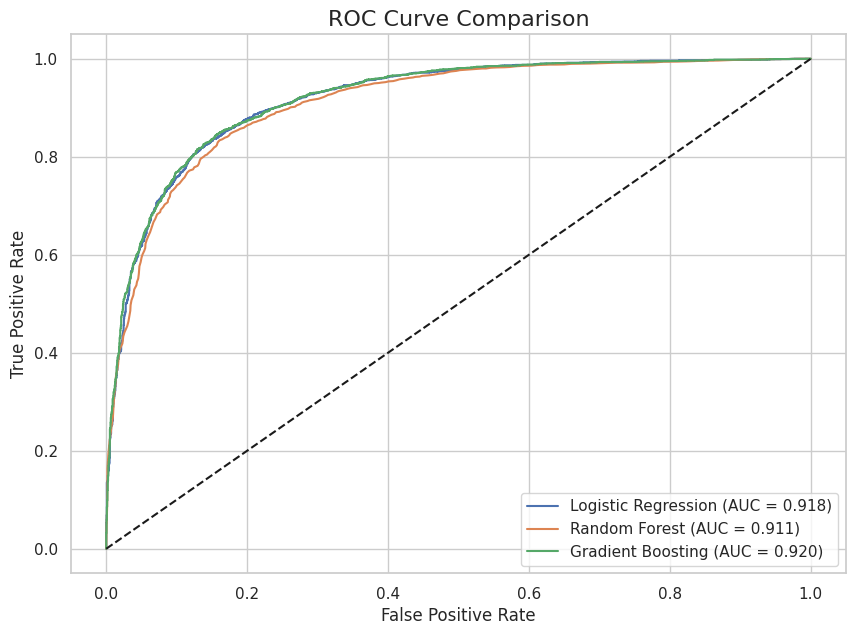

In [ ]:


# ---- Get predicted probabilities (positive class) ----
y_pred_proba_log = log_reg.predict_proba(X_test)[:, 1]
y_pred_proba_rf  = rf.predict_proba(X_test)[:, 1]
y_pred_proba_gb  = gb.predict_proba(X_test)[:, 1]

# ---- Compute ROC curve points ----
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_pred_proba_rf)
fpr_gb,  tpr_gb,  _ = roc_curve(y_test, y_pred_proba_gb)

# ---- Compute AUC values ----
auc_log = roc_auc_score(y_test, y_pred_proba_log)
auc_rf  = roc_auc_score(y_test, y_pred_proba_rf)
auc_gb  = roc_auc_score(y_test, y_pred_proba_gb)

# ---- Plot ROC curves ----
plt.figure(figsize=(10, 7))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_rf,  tpr_rf,  label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_gb,  tpr_gb,  label=f"Gradient Boosting (AUC = {auc_gb:.3f})")

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC Curve Comparison", fontsize=16)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
'''
it's near 1.0 higher than 0.5
FP rate: How often the model wrongly flags a normal person as depressed.
TP rate: How often the model correctly detects depressed cases.
The difference is VERY small → all models are strong.

ROC curve shows the model’s ability to distinguish between classes across
different thresholds, and AUC close to 1 indicates excellent classification capability.
'''

"\nit's near 1.0 higher than 0.5\nFP rate: How often the model wrongly flags a normal person as depressed.\nTP rate: How often the model correctly detects depressed cases.\nThe difference is VERY small → all models are strong.\n\nROC curve shows the model’s ability to distinguish between classes across\ndifferent thresholds, and AUC close to 1 indicates excellent classification capability.\n"